In [1]:
# ============================================================
# MERGE ALL CSV FILES INTO ONE DATASET
# ============================================================

import pandas as pd
import glob
import os

# ------------------------------------------------------------
# Folder containing all class CSV files
# ------------------------------------------------------------

CSV_FOLDER = "/content/csvs"

# Example:
# /content/csvs/
#   class0.csv
#   class1.csv
#   class2.csv
#   ...

# ------------------------------------------------------------
# Find all CSV files
# ------------------------------------------------------------

csv_files = glob.glob(
    os.path.join(CSV_FOLDER, "*.csv")
)

print(f"Found {len(csv_files)} CSV files")

for f in csv_files:
    print(" -", os.path.basename(f))

# ------------------------------------------------------------
# Read first CSV
# ------------------------------------------------------------

base_df = pd.read_csv(csv_files[0])

base_cols = list(base_df.columns)

print("\nReference column count:", len(base_cols))

# ------------------------------------------------------------
# Validate all CSVs have same columns
# ------------------------------------------------------------

all_dfs = [base_df]

for file in csv_files[1:]:

    df = pd.read_csv(file)

    cols = list(df.columns)

    if cols != base_cols:

        print(f"\n[SKIPPED] Column mismatch:")
        print(file)

        missing = set(base_cols) - set(cols)
        extra   = set(cols) - set(base_cols)

        print("Missing:", missing)
        print("Extra:", extra)

        continue

    print(f"[OK] {os.path.basename(file)}")

    all_dfs.append(df)

# ------------------------------------------------------------
# Merge
# ------------------------------------------------------------

merged_df = pd.concat(

    all_dfs,

    ignore_index=True
)

print("\nMerged shape:", merged_df.shape)

# ------------------------------------------------------------
# Shuffle dataset
# ------------------------------------------------------------

merged_df = merged_df.sample(

    frac=1,

    random_state=42
).reset_index(drop=True)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

OUTPUT_FILE = "multicast_training_dataset.csv"

merged_df.to_csv(

    OUTPUT_FILE,

    index=False
)

print(f"\nSaved merged dataset -> {OUTPUT_FILE}")

# ------------------------------------------------------------
# Label distribution
# ------------------------------------------------------------

if 'label_name' in merged_df.columns:

    print("\nLabel Distribution:\n")

    print(
        merged_df['label_name']
        .value_counts()
    )

Found 9 CSV files
 - r2-sw1_final1_class7_window_flow.csv
 - r2-sw1_final_class2_window_flow.csv
 - r2-sw1_final_1_class1_window_flow.csv
 - r2-sw1_final0_class7_window_flow (1).csv
 - r2-sw1_final0_class8_window_flow.csv
 - r2-sw1_final1_class2_window_flow.csv
 - r2-sw1_final_class0_window_flow.csv
 - r2-sw1_final_class1_class1_window_flow.csv
 - r2-sw1_final_class4_window_flow.csv

Reference column count: 64
[OK] r2-sw1_final_class2_window_flow.csv
[OK] r2-sw1_final_1_class1_window_flow.csv
[OK] r2-sw1_final0_class7_window_flow (1).csv
[OK] r2-sw1_final0_class8_window_flow.csv
[OK] r2-sw1_final1_class2_window_flow.csv
[OK] r2-sw1_final_class0_window_flow.csv
[OK] r2-sw1_final_class1_class1_window_flow.csv
[OK] r2-sw1_final_class4_window_flow.csv

Merged shape: (7745, 64)

Saved merged dataset -> multicast_training_dataset.csv

Label Distribution:

label_name
BENIGN         6446
IGMP_SPOOF      310
DATA_FLOOD      280
PIM_HELLO       275
QUERY_FLOOD     261
IGMP_FLOOD      173
Name: c

In [2]:
!pip install -q xgboost scikit-learn imbalanced-learn shap

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import shap

In [5]:
df = pd.read_csv("/content/multicast_training_dataset.csv")

print(df.shape)

df.head()

(7745, 64)


,source_pcap,pcap_class,bucket_id,label,label_name,window_duration_s,total_flows,total_pkts,total_bytes,pkt_rate,...,mcast_icmp_rate,pkt_size_mean,pkt_size_std,pkt_size_min,pkt_size_max,iat_mean_s,iat_std_s,iat_min_s,iat_max_s,burstiness
0,/content/r2-sw1_final1.pcap,7,1720,0,BENIGN,32.093,95,208,40739,6.4812,...,0.0,188.5037,146.9296,42.0,781.0,0.104766,0.044407,0.001,0.252,0.4239
1,/content/r2-sw1_final1.pcap,7,1163,0,BENIGN,25.015,101,183,29991,7.3156,...,0.0,169.2019,154.4697,42.0,840.0,0.096760,0.035654,0.002,0.212,0.3685
2,/content/r2-sw1_final_1.pcap,1,140,0,BENIGN,15.733,179,265,42538,16.8436,...,0.0,160.1624,188.7528,42.0,839.0,0.055989,0.034973,0.000,0.178,0.6246
3,/content/r2-sw1_final1.pcap,2,235,2,IGMP_SPOOF,30.774,114,879,67591,28.5631,...,0.0,149.5341,145.9909,42.0,812.0,0.087257,0.039649,0.001,0.240,0.4544
4,/content/r2-sw1_final1.pcap,7,132,0,BENIGN,36.907,95,800,481522,21.6761,...,0.0,189.2300,189.1323,42.0,829.0,0.104936,0.053219,0.004,0.409,0.5072


In [6]:
#  basic validation
print(df.isnull().sum().sort_values(ascending=False).head(20))

source_pcap          0
pcap_class           0
bucket_id            0
label                0
label_name           0
window_duration_s    0
total_flows          0
total_pkts           0
total_bytes          0
pkt_rate             0
byte_rate            0
flow_rate            0
igmp_pkts            0
pim_pkts             0
ospf_pkts            0
mld_pkts             0
udp_pkts             0
tcp_pkts             0
icmp_pkts            0
igmp_rate            0
dtype: int64


In [7]:
# Remove Invalid Rows
df = df.replace([np.inf, -np.inf], np.nan)

df = df.dropna()

print(df.shape)

(7745, 64)


In [8]:
df['label_name'].value_counts()

,count
label_name,
BENIGN,6446
IGMP_SPOOF,310
DATA_FLOOD,280
PIM_HELLO,275
QUERY_FLOOD,261
IGMP_FLOOD,173


In [9]:
drop_cols = [

    # metadata
    'source_pcap',
    'bucket_id',

    # direct labels
    'label',
    'label_name',

    # attack generator metadata
    'pcap_class'
]

X = df.drop(columns=drop_cols)

y = df['label_name']

print(X.shape)

(7745, 59)


In [10]:
print(X.columns.tolist())

['window_duration_s', 'total_flows', 'total_pkts', 'total_bytes', 'pkt_rate', 'byte_rate', 'flow_rate', 'igmp_pkts', 'pim_pkts', 'ospf_pkts', 'mld_pkts', 'udp_pkts', 'tcp_pkts', 'icmp_pkts', 'igmp_rate', 'pim_rate', 'ospf_rate', 'mld_rate', 'igmp_ratio', 'pim_ratio', 'udp_ratio', 'tcp_ratio', 'icmp_ratio', 'igmp_join_pkts', 'igmp_leave_pkts', 'igmp_query_pkts', 'igmp_join_rate', 'igmp_leave_rate', 'igmp_query_rate', 'pim_hello_pkts', 'pim_hello_rate', 'mld_report_pkts', 'mld_report_rate', 'unique_mcast_groups', 'mcast_group_rate', 'group_entropy', 'group_churn_rate', 'group_reuse_ratio', 'unique_src_ips', 'unique_src_ips_igmp', 'src_ip_entropy', 'control_data_ratio', 'state_pressure', 'query_join_ratio', 'multicast_fanout', 'mcast_udp_pkts', 'mcast_udp_bytes', 'mcast_udp_rate', 'mcast_icmp_pkts', 'mcast_icmp_rate', 'pkt_size_mean', 'pkt_size_std', 'pkt_size_min', 'pkt_size_max', 'iat_mean_s', 'iat_std_s', 'iat_min_s', 'iat_max_s', 'burstiness']


In [11]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

print(le.classes_)

['BENIGN' 'DATA_FLOOD' 'IGMP_FLOOD' 'IGMP_SPOOF' 'PIM_HELLO' 'QUERY_FLOOD']


In [13]:
for i, class_name in enumerate(le.classes_):
    print(f"{class_name}: {i}")

BENIGN: 0
DATA_FLOOD: 1
IGMP_FLOOD: 2
IGMP_SPOOF: 3
PIM_HELLO: 4
QUERY_FLOOD: 5


In [12]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_encoded,

    test_size=0.2,

    random_state=42,

    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(6196, 59)
(1549, 59)


In [14]:
classes = np.unique(y_train)

weights = compute_class_weight(

    class_weight='balanced',

    classes=classes,

    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.20024562083898909), np.int64(1): np.float64(4.6101190476190474), np.int64(2): np.float64(7.483091787439614), np.int64(3): np.float64(4.163978494623656), np.int64(4): np.float64(4.693939393939394), np.int64(5): np.float64(4.940988835725678)}


In [15]:
model = XGBClassifier(

    objective='multi:softprob',

    num_class=len(le.classes_),

    n_estimators=300,

    max_depth=8,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    gamma=1,

    min_child_weight=3,

    reg_lambda=1,

    reg_alpha=0.2,

    random_state=42,

    tree_method='hist',

    eval_metric='mlogloss'
)

In [16]:
model.fit(

    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=6, ...)

In [17]:
y_pred = model.predict(X_test)

In [18]:
acc = accuracy_score(y_test, y_pred)

f1 = f1_score(

    y_test,
    y_pred,

    average='weighted'
)

print(f"Accuracy : {acc:.4f}")

print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9942
F1 Score : 0.9941


In [19]:
print(

    classification_report(

        y_test,
        y_pred,

        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

      BENIGN       0.99      1.00      1.00      1289
  DATA_FLOOD       1.00      1.00      1.00        56
  IGMP_FLOOD       1.00      1.00      1.00        35
  IGMP_SPOOF       0.98      0.90      0.94        62
   PIM_HELLO       0.98      0.98      0.98        55
 QUERY_FLOOD       1.00      1.00      1.00        52

    accuracy                           0.99      1549
   macro avg       0.99      0.98      0.99      1549
weighted avg       0.99      0.99      0.99      1549



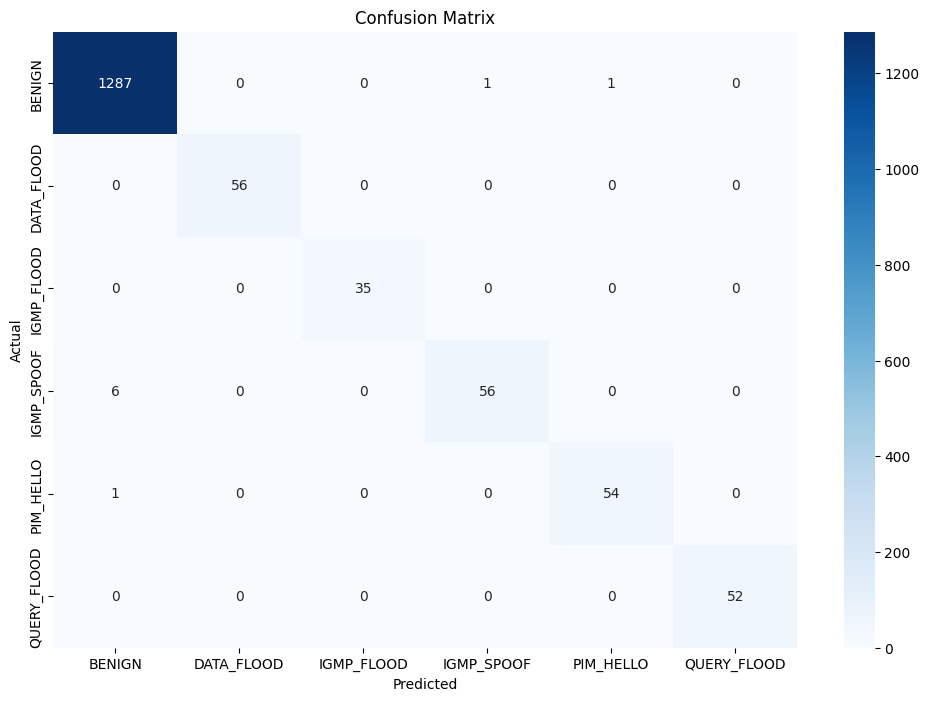

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,8))

sns.heatmap(

    cm,

    annot=True,
    fmt='d',

    xticklabels=le.classes_,
    yticklabels=le.classes_,

    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [21]:
importance = model.feature_importances_

feat_imp = pd.DataFrame({

    'feature': X.columns,
    'importance': importance
})

feat_imp = feat_imp.sort_values(

    by='importance',
    ascending=False
)

feat_imp.head(25)

,feature,importance
58,burstiness,0.218551
41,control_data_ratio,0.085632
29,pim_hello_pkts,0.084292
50,pkt_size_mean,0.069733
39,unique_src_ips_igmp,0.063109
27,igmp_leave_rate,0.052664
8,pim_pkts,0.044094
28,igmp_query_rate,0.034808
26,igmp_join_rate,0.030598
37,group_reuse_ratio,0.023159


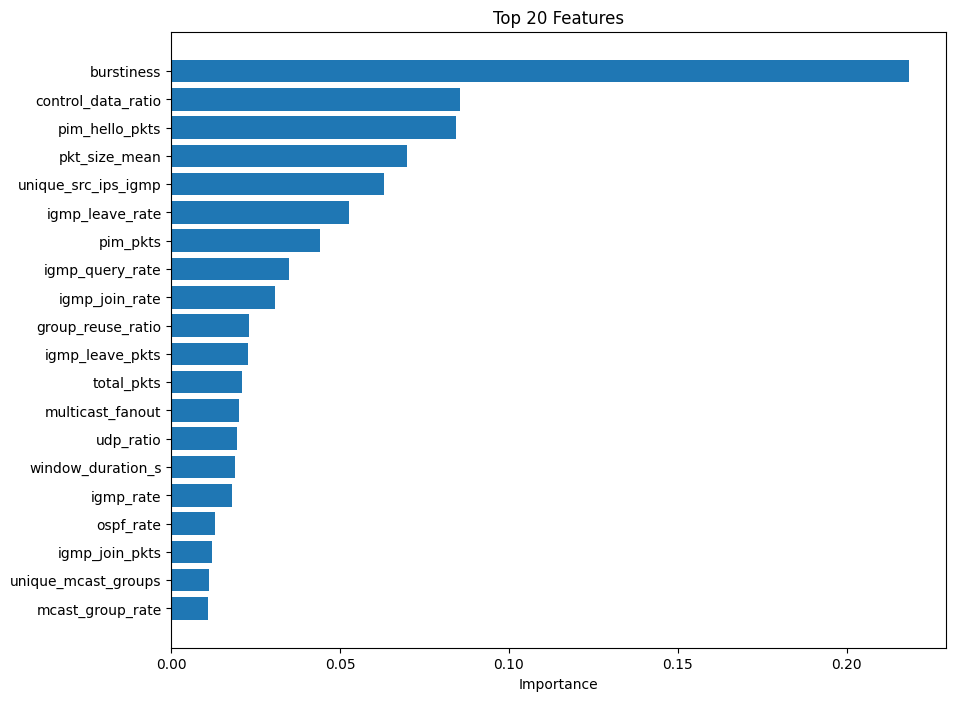

In [22]:
topk = feat_imp.head(20)

plt.figure(figsize=(10,8))

plt.barh(

    topk['feature'][::-1],
    topk['importance'][::-1]
)

plt.xlabel("Importance")

plt.title("Top 20 Features")

plt.show()

In [23]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test.iloc[:200])

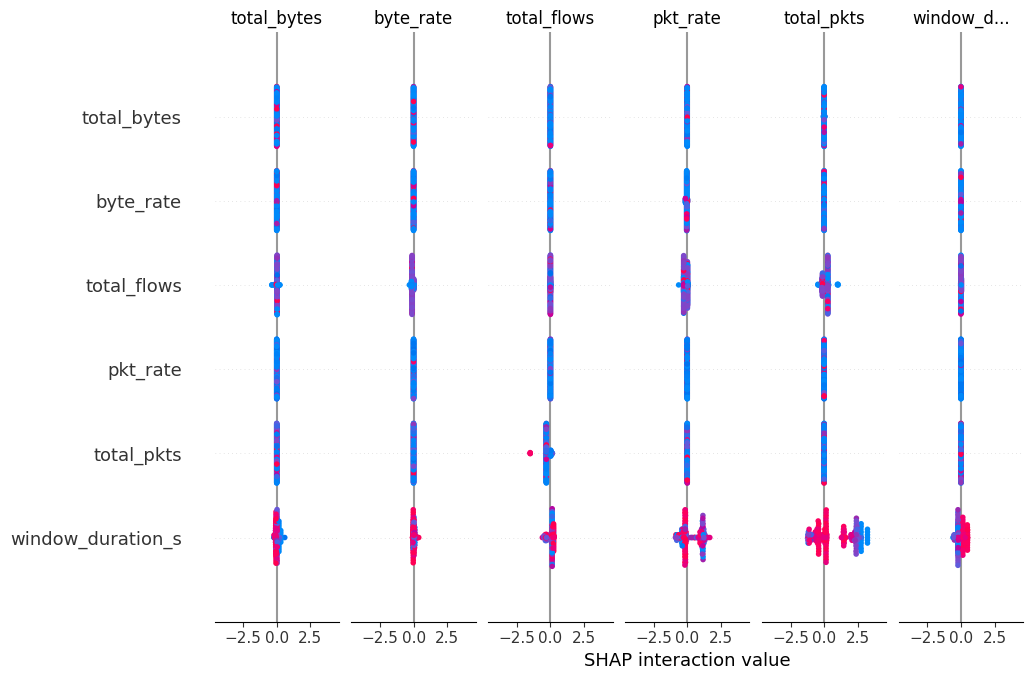

In [24]:
shap.summary_plot(

    shap_values,

    X_test.iloc[:200]
)

In [25]:
model.save_model("multicast_xgboost_model.json")

In [26]:
import joblib

joblib.dump(

    le,

    "label_encoder.pkl"
)

['label_encoder.pkl']

In [27]:
from google.colab import files

# files.download("multicast_xgboost_model.json")

files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **TEST ON UNSEEN DATA**

In [34]:
# ============================================================
# LOAD MODEL + TEST ON UNSEEN WINDOW CSV
# ============================================================

import pandas as pd
import numpy as np
import joblib

from xgboost import XGBClassifier

# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------

model = XGBClassifier()

model.load_model(
    "/content/multicast_xgboost_model.json"
)

# ------------------------------------------------------------
# LOAD LABEL ENCODER
# ------------------------------------------------------------

le = joblib.load(
    "label_encoder.pkl"
)

# ------------------------------------------------------------
# LOAD UNSEEN CSV
# ------------------------------------------------------------

test_df = pd.read_csv(
    "/content/class2_r1-sw1_class2_window_flow.csv"
)

print(test_df.shape)

test_df.head()

(431, 64)


,source_pcap,pcap_class,bucket_id,label,label_name,window_duration_s,total_flows,total_pkts,total_bytes,pkt_rate,...,mcast_icmp_rate,pkt_size_mean,pkt_size_std,pkt_size_min,pkt_size_max,iat_mean_s,iat_std_s,iat_min_s,iat_max_s,burstiness
0,/content/class2_r1-sw1.pcap,2,0,0,BENIGN,29.978,100,970,905493,32.3571,...,0.0,185.3927,222.6721,50.0,1145.4882,0.100939,0.045112,0.000,0.230,0.4469
1,/content/class2_r1-sw1.pcap,2,1,0,BENIGN,15.455,91,171,25619,11.0644,...,0.0,150.5010,148.9994,50.0,842.0000,0.108933,0.050405,0.000,0.292,0.4627
2,/content/class2_r1-sw1.pcap,2,2,2,IGMP_SPOOF,39.771,89,1130,68340,28.4127,...,0.0,137.3615,157.2914,42.0,842.0000,0.112409,0.058650,0.000,0.325,0.5218
3,/content/class2_r1-sw1.pcap,2,3,2,IGMP_SPOOF,37.800,86,1177,72520,31.1376,...,0.0,142.6656,157.0324,42.0,831.0000,0.115576,0.057514,0.002,0.325,0.4976
4,/content/class2_r1-sw1.pcap,2,4,2,IGMP_SPOOF,35.802,83,1169,70770,32.6518,...,0.0,138.8850,160.7464,42.0,831.0000,0.119159,0.060996,0.002,0.325,0.5119


In [35]:
# ============================================================
# REMOVE INVALID VALUES
# ============================================================

test_df = test_df.replace(
    [np.inf, -np.inf],
    np.nan
)

test_df = test_df.dropna()

print(test_df.shape)

(431, 64)


In [36]:
# ============================================================
# DROP NON-BEHAVIORAL COLUMNS
# ============================================================

drop_cols = [

    'source_pcap',
    'bucket_id',

    'label',
    'label_name',

    'pcap_class'
]

# Drop only columns that exist
drop_existing = [

    c for c in drop_cols
    if c in test_df.columns
]

X_unseen = test_df.drop(
    columns=drop_existing
)

print(X_unseen.shape)

(431, 59)


In [37]:
# ============================================================
# PREDICT(igmp spoof)
# ============================================================

pred_encoded = model.predict(
    X_unseen
)

pred_labels = le.inverse_transform(
    pred_encoded.astype(int)
)

# Add predictions
test_df['predicted_label'] = pred_labels

test_df[['predicted_label']].head()

,predicted_label
0,BENIGN
1,BENIGN
2,IGMP_SPOOF
3,IGMP_SPOOF
4,IGMP_SPOOF


In [38]:
# ============================================================
# PREDICTION DISTRIBUTION
# ============================================================

print(

    test_df['predicted_label']
    .value_counts()
)

predicted_label
BENIGN        365
IGMP_SPOOF     66
Name: count, dtype: int64


In [39]:
# ============================================================
# OPTIONAL EVALUATION
# ============================================================

from sklearn.metrics import classification_report

if 'label_name' in test_df.columns:

    print(

        classification_report(

            test_df['label_name'],

            test_df['predicted_label']
        )
    )

              precision    recall  f1-score   support

      BENIGN       0.88      1.00      0.94       323
  IGMP_SPOOF       1.00      0.61      0.76       108

    accuracy                           0.90       431
   macro avg       0.94      0.81      0.85       431
weighted avg       0.91      0.90      0.89       431



# **multicast data flood**

In [45]:
test_df = pd.read_csv(
    "/content/class8_r1-sw1_class8_window_flow.csv"
)

print(test_df.shape)

test_df.head()

(291, 64)


,source_pcap,pcap_class,bucket_id,label,label_name,window_duration_s,total_flows,total_pkts,total_bytes,pkt_rate,...,mcast_icmp_rate,pkt_size_mean,pkt_size_std,pkt_size_min,pkt_size_max,iat_mean_s,iat_std_s,iat_min_s,iat_max_s,burstiness
0,/content/class8_r1-sw1.pcap,8,0,8,DATA_FLOOD,35.477,87,1596,2031770,44.9869,...,0.0,195.8166,268.3024,42.0,1430.7957,0.116012,0.058684,0.000,0.381,0.5058
1,/content/class8_r1-sw1.pcap,8,1,0,BENIGN,33.392,82,189,32239,5.6600,...,0.0,158.3313,160.3201,42.0,811.0000,0.122074,0.057098,0.000,0.381,0.4677
2,/content/class8_r1-sw1.pcap,8,2,0,BENIGN,31.435,81,186,32495,5.9170,...,0.0,163.1405,160.3532,42.0,811.0000,0.123750,0.057295,0.000,0.322,0.4630
3,/content/class8_r1-sw1.pcap,8,3,0,BENIGN,29.467,78,183,32679,6.2103,...,0.0,167.6601,165.1208,42.0,811.0000,0.128481,0.063832,0.000,0.322,0.4968
4,/content/class8_r1-sw1.pcap,8,4,0,BENIGN,13.540,77,149,25535,11.0044,...,0.0,172.0165,177.5561,42.0,811.0000,0.131145,0.061756,0.008,0.322,0.4709


In [46]:
# ============================================================
# REMOVE INVALID VALUES
# ============================================================

test_df = test_df.replace(
    [np.inf, -np.inf],
    np.nan
)

test_df = test_df.dropna()

print(test_df.shape)

(291, 64)


In [47]:
# ============================================================
# DROP NON-BEHAVIORAL COLUMNS
# ============================================================

drop_cols = [

    'source_pcap',
    'bucket_id',

    'label',
    'label_name',

    'pcap_class'
]

# Drop only columns that exist
drop_existing = [

    c for c in drop_cols
    if c in test_df.columns
]

X_unseen = test_df.drop(
    columns=drop_existing
)

print(X_unseen.shape)

(291, 59)


In [48]:
# ============================================================
# PREDICT(multiclass data flood)
# ============================================================

pred_encoded = model.predict(
    X_unseen
)

pred_labels = le.inverse_transform(
    pred_encoded.astype(int)
)

# Add predictions
test_df['predicted_label'] = pred_labels

test_df[['predicted_label']].head()

,predicted_label
0,BENIGN
1,BENIGN
2,BENIGN
3,BENIGN
4,BENIGN


In [49]:
# ============================================================
# PREDICTION DISTRIBUTION
# ============================================================

print(

    test_df['predicted_label']
    .value_counts()
)

predicted_label
BENIGN    291
Name: count, dtype: int64


In [50]:
# ============================================================
# OPTIONAL EVALUATION
# ============================================================

from sklearn.metrics import classification_report

if 'label_name' in test_df.columns:

    print(

        classification_report(

            test_df['label_name'],

            test_df['predicted_label']
        )
    )

              precision    recall  f1-score   support

      BENIGN       0.57      1.00      0.72       165
  DATA_FLOOD       0.00      0.00      0.00       126

    accuracy                           0.57       291
   macro avg       0.28      0.50      0.36       291
weighted avg       0.32      0.57      0.41       291



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
